In [1]:
import os
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from tqdm import tqdm
import random

random.seed(42)

In [2]:
image_dir = "./dataset/imagesTr"
label_dir = "./dataset/labelsTr"

image_files = sorted(glob(os.path.join(image_dir, "*.nii.gz")))
label_files = [os.path.join(label_dir, os.path.basename(f)) for f in image_files]

# Randomly select 3 indices
sample_indices = random.sample(range(len(image_files)), 3)
sample_images = [image_files[i] for i in sample_indices]
sample_labels = [label_files[i] for i in sample_indices]

In [3]:
label_map = {
    1: "Edema",
    2: "Non-enhancing tumor",
    3: "Enhancing tumor"
}

In [4]:
def get_multilabel_vector(label_data):
    labels_present = sorted(set(np.unique(label_data)) - {0})  # exclude background
    multilabel = [int(k in labels_present) for k in label_map]
    label_names = [label_map[k] for k in labels_present]
    return multilabel, label_names

In [5]:
def plot_slices_with_labels(image_path, label_path):
    image_nifti = nib.load(image_path)
    label_nifti = nib.load(label_path)

    image = image_nifti.get_fdata()  # shape: H x W x D x C
    label = label_nifti.get_fdata().astype(int)  # shape: H x W x D

    mid_slice = image.shape[2] // 2
    multilabel, label_names = get_multilabel_vector(label)

    fig, axs = plt.subplots(1, 5, figsize=(22, 5))
    axs[0].imshow(image[:, :, mid_slice, 0], cmap="gray")
    axs[0].set_title("FLAIR")
    axs[1].imshow(image[:, :, mid_slice, 1], cmap="gray")
    axs[1].set_title("T1w")
    axs[2].imshow(image[:, :, mid_slice, 2], cmap="gray")
    axs[2].set_title("T1gd")
    axs[3].imshow(image[:, :, mid_slice, 3], cmap="gray")
    axs[3].set_title("T2w")
    axs[4].imshow(label[:, :, mid_slice], cmap="nipy_spectral", vmin=0, vmax=3)
    axs[4].set_title("Label Map")

    for ax in axs:
        ax.axis("off")

    # Add label info as a supertitle
    fig.suptitle(f"Assigned Labels: {', '.join(label_names) if label_names else 'None'}", fontsize=14, y=1.05)
    plt.tight_layout()
    plt.show()


Visualizing: BRATS_328.nii.gz


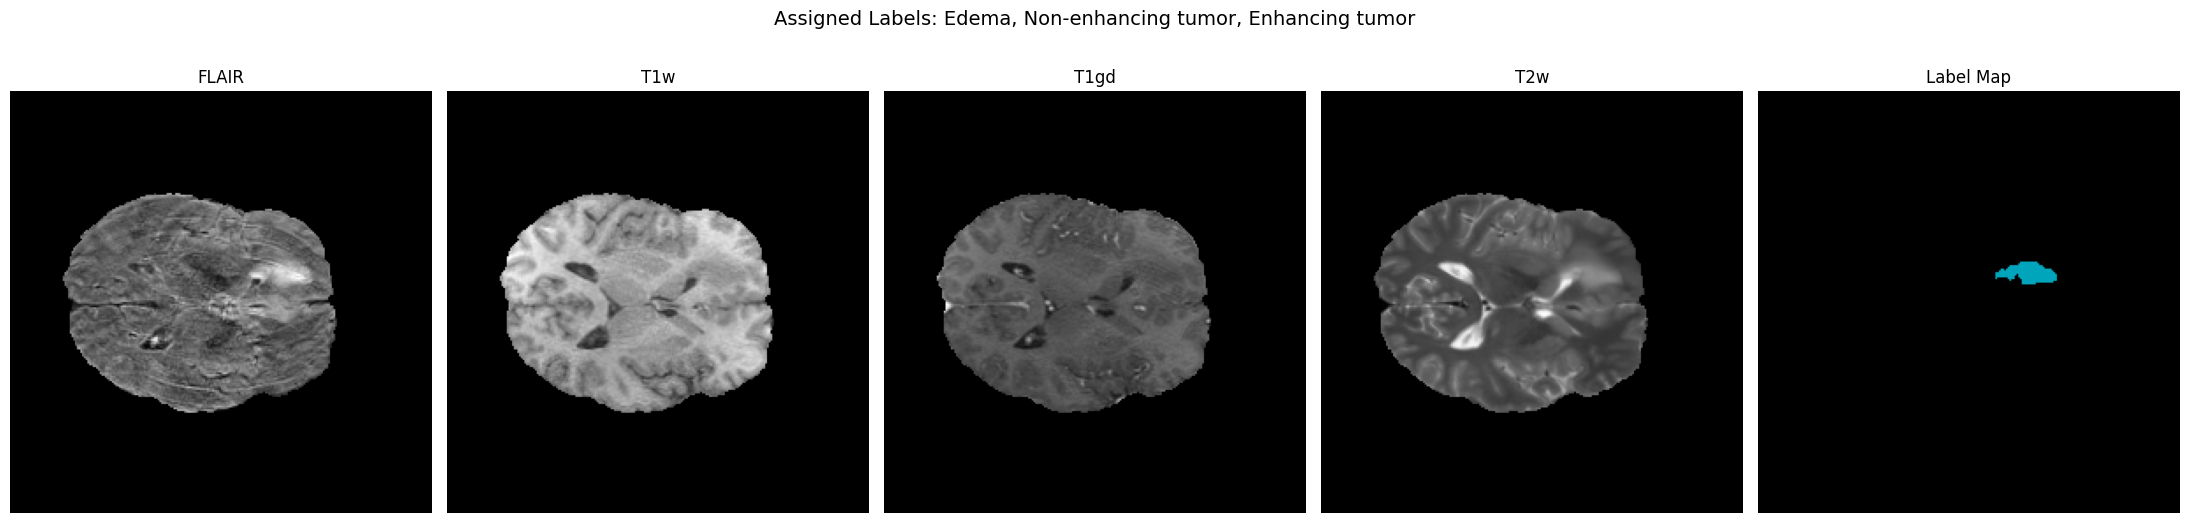


Visualizing: BRATS_058.nii.gz


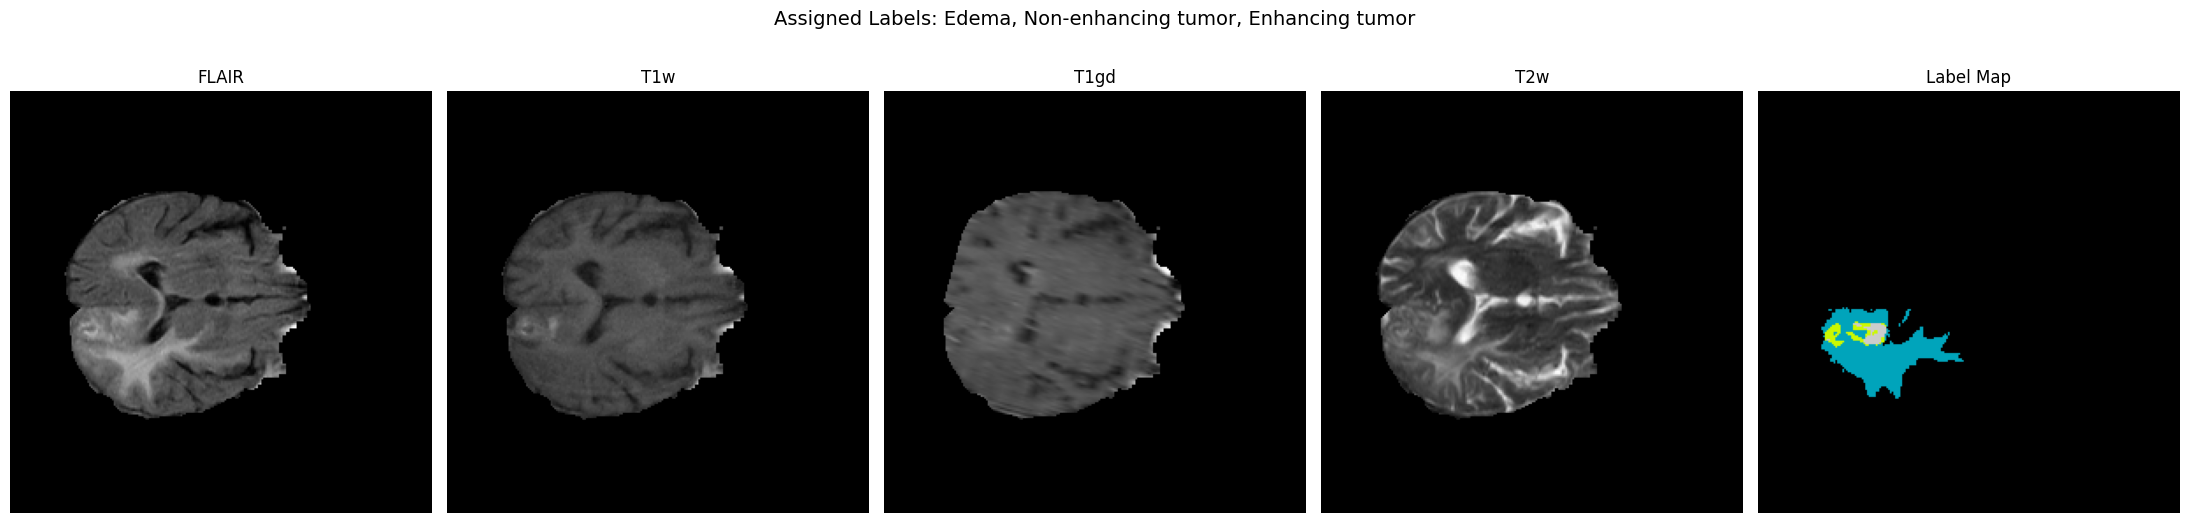


Visualizing: BRATS_013.nii.gz


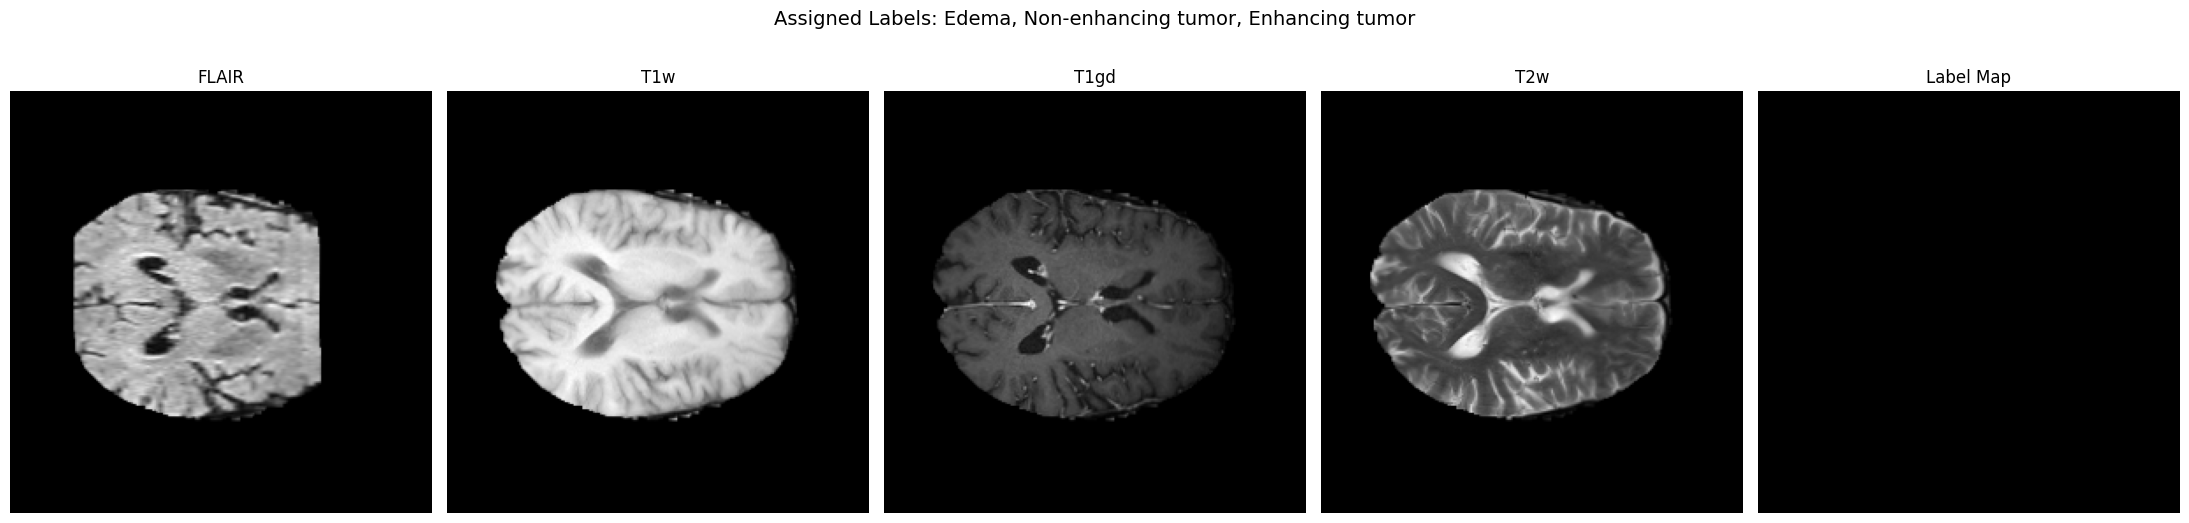

In [6]:
for img, lbl in zip(sample_images, sample_labels):
    print(f"\nVisualizing: {os.path.basename(img)}")
    plot_slices_with_labels(img, lbl)

In [6]:
import os
import nibabel as nib
import numpy as np
import torch
from torch.utils.data import Dataset
import random

In [7]:
class BRATSSliceDataset(Dataset):
    def __init__(self, image_label_pairs, modality_index=0, transform=None):
        self.slice_indices = []  # list of (image_path, label_path, slice_index)
        self.modality_index = modality_index
        self.transform = transform

        for pair in image_label_pairs:
            img_path = pair['image']
            label_path = pair['label']

            img_nii = nib.load(img_path)
            label_nii = nib.load(label_path)

            img_data = img_nii.get_fdata()[..., modality_index]
            label_data = label_nii.get_fdata()

            for i in range(img_data.shape[2]):
                if np.any(label_data[:, :, i] > 0):  # tumor exists in slice
                    self.slice_indices.append((img_path, label_path, i))

    def __len__(self):
        return len(self.slice_indices)

    def __getitem__(self, idx):
        img_path, label_path, slice_idx = self.slice_indices[idx]

        image = nib.load(img_path).get_fdata()[..., self.modality_index][:, :, slice_idx]
        mask = nib.load(label_path).get_fdata()[:, :, slice_idx]

        # Normalize image
        image = (image - np.mean(image)) / (np.std(image) + 1e-5)

        # Add channel dim
        image = np.expand_dims(image, axis=0)

        if self.transform:
            image, mask = self.transform(image, mask)

        return torch.tensor(image, dtype=torch.float32), torch.tensor(mask, dtype=torch.long)


In [8]:
import matplotlib.pyplot as plt
import random

def visualize_sample(dataset, num_samples=5):
    """Randomly visualize a few image slices and their masks"""
    indices = random.sample(range(len(dataset)), num_samples)
    
    for i, idx in enumerate(indices):
        image, mask = dataset[idx]
        image = image[0]  # remove channel dim

        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Image Slice {idx}")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(mask, cmap='nipy_spectral', interpolation='none')
        plt.title("Segmentation Mask")
        plt.axis('off')

        plt.tight_layout()
        plt.show()


In [9]:
import json
import os 
from pathlib import Path

def load_train_pairs(json_path, base_dir):
    with open(json_path) as f:
        data_info = json.load(f)

    pairs = data_info['training']
    
    full_pairs = []
    for p in pairs:
        full_image = os.path.join(base_dir, p['image'].lstrip("./"))
        full_label = os.path.join(base_dir, p['label'].lstrip("./"))
        full_pairs.append({'image': full_image, 'label': full_label})
    
    return full_pairs

# Example usage
dataset_base_dir = Path('./dataset').resolve()  # <-- replace this
train_pairs = load_train_pairs('./dataset/dataset.json', dataset_base_dir)

# Then load the dataset as before
dataset = BRATSSliceDataset(train_pairs, modality_index=0)

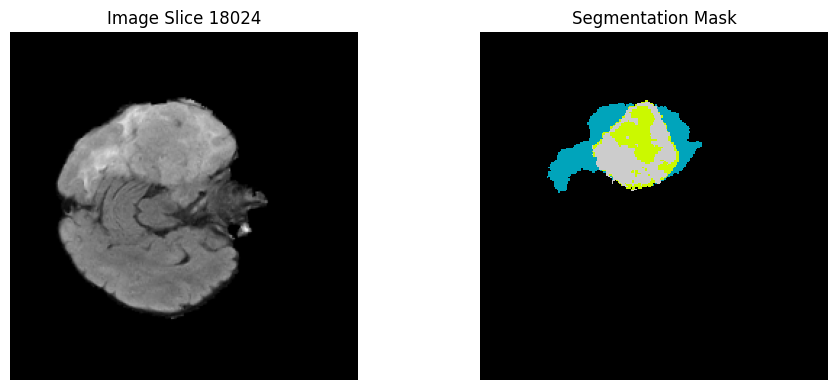

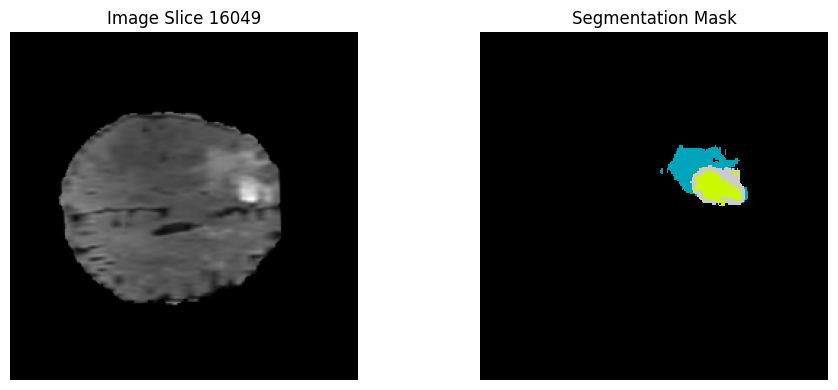

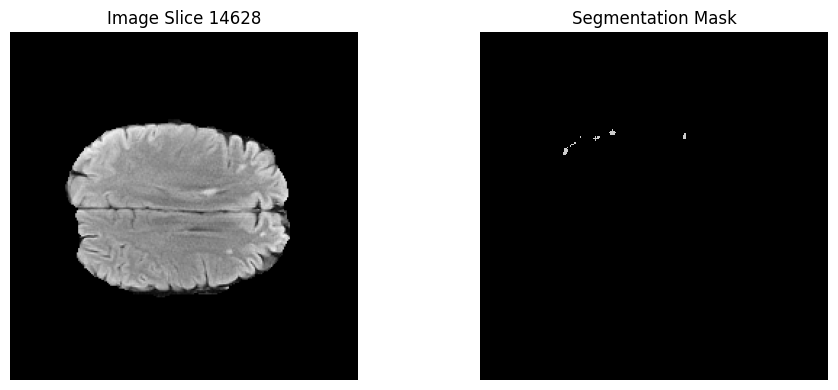

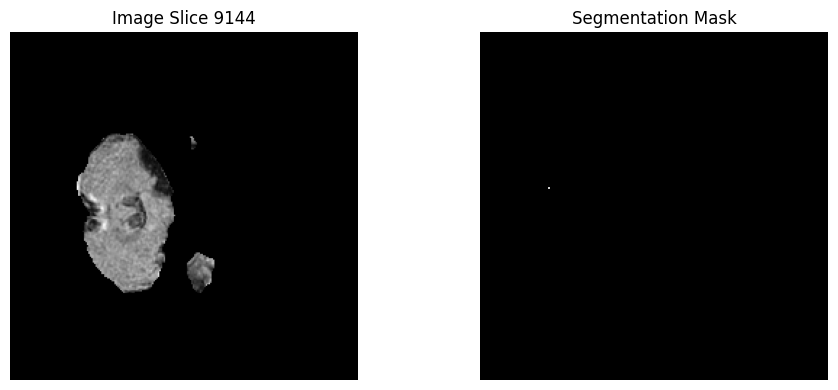

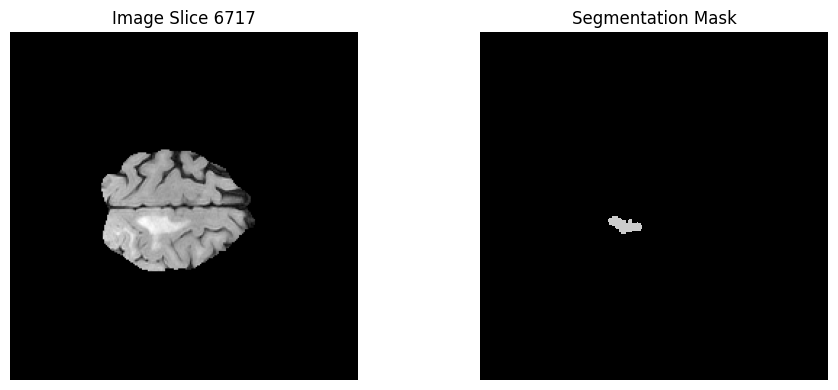

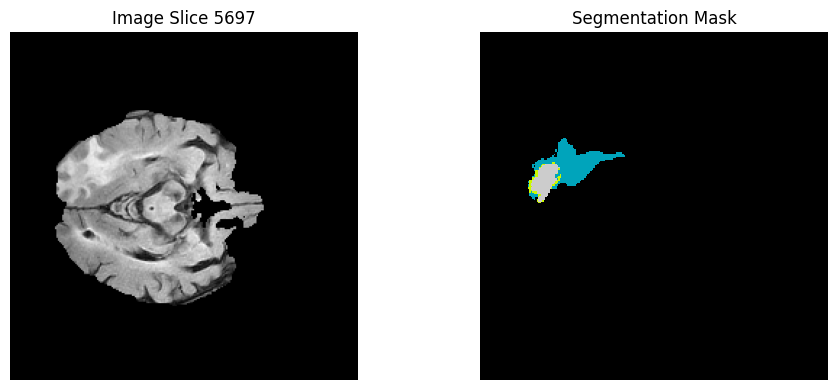

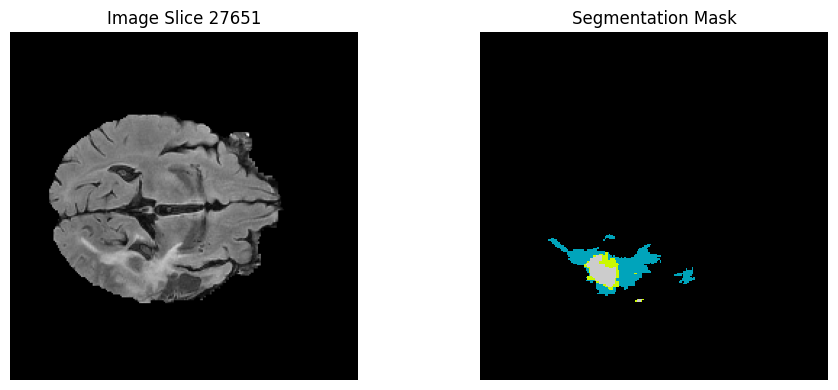

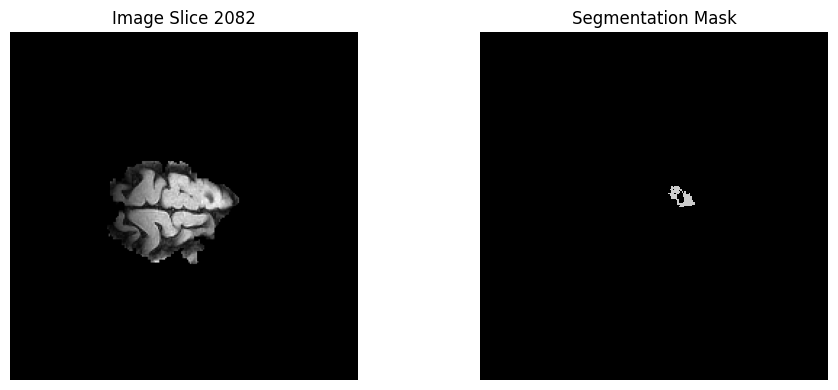

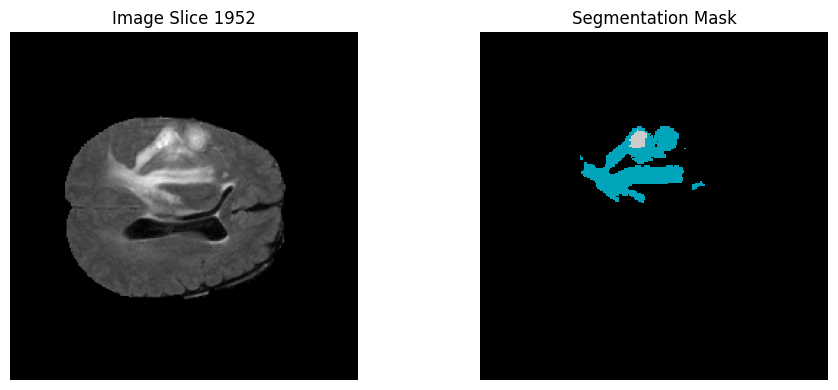

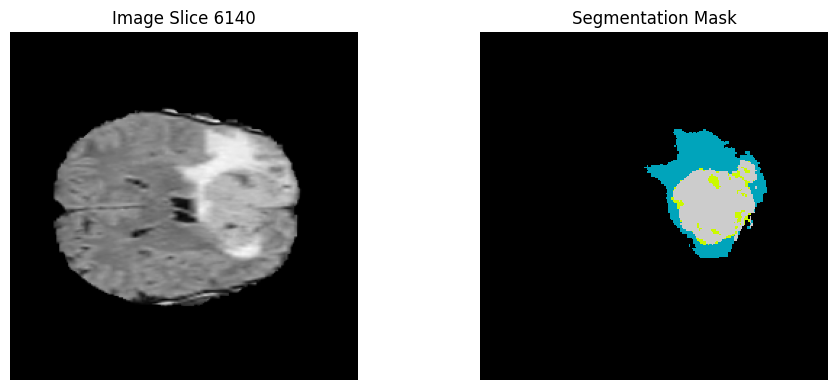

In [11]:
# Visualize
visualize_sample(dataset, num_samples=10)

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class UNet2D(nn.Module):
    def __init__(self, in_channels=1, out_channels=4, features=[64, 128, 256, 512]):
        super(UNet2D, self).__init__()

        self.encoder = nn.ModuleList()
        self.decoder = nn.ModuleList()

        # Encoder (Down)
        for feature in features:
            self.encoder.append(self._conv_block(in_channels, feature))
            in_channels = feature

        # Bottleneck
        self.bottleneck = self._conv_block(features[-1], features[-1]*2)

        # Decoder (Up)
        for feature in reversed(features):
            self.decoder.append(nn.ConvTranspose2d(feature*2, feature, kernel_size=2, stride=2))
            self.decoder.append(self._conv_block(feature*2, feature))

        # Final output layer
        self.output_layer = nn.Conv2d(features[0], out_channels, kernel_size=1)

    def _conv_block(self, in_channels, out_channels):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        skip_connections = []
        for down in self.encoder:
            x = down(x)
            skip_connections.append(x)
            x = F.max_pool2d(x, kernel_size=2, stride=2)

        x = self.bottleneck(x)
        skip_connections = skip_connections[::-1]

        for idx in range(0, len(self.decoder), 2):
            x = self.decoder[idx](x)
            skip_connection = skip_connections[idx // 2]

            if x.shape != skip_connection.shape:
                x = F.interpolate(x, size=skip_connection.shape[2:])

            x = torch.cat((skip_connection, x), dim=1)
            x = self.decoder[idx + 1](x)

        return self.output_layer(x)


In [11]:
import torch
from torch.utils.data import DataLoader
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm

def dice_score(preds, targets, num_classes=4):
    """Compute Dice score for each class and return average"""
    preds = torch.argmax(preds, dim=1)
    dice = []

    for cls in range(num_classes):
        pred_cls = (preds == cls).float()
        target_cls = (targets == cls).float()

        intersection = (pred_cls * target_cls).sum()
        union = pred_cls.sum() + target_cls.sum()
        dice_cls = (2. * intersection + 1e-5) / (union + 1e-5)
        dice.append(dice_cls.item())
    
    return sum(dice) / len(dice)


In [12]:
def train_model(model, train_dataset, val_dataset=None, num_epochs=10, batch_size=8, lr=1e-3, device='cuda' if torch.cuda.is_available() else 'cpu'):
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False) if val_dataset else None

    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        train_dice = 0

        loop = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}')
        for images, masks in loop:
            images, masks = images.to(device), masks.to(device)

            preds = model(images)
            loss = criterion(preds, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            train_dice += dice_score(preds, masks)

            loop.set_postfix(loss=loss.item())

        avg_loss = train_loss / len(train_loader)
        avg_dice = train_dice / len(train_loader)
        print(f'Epoch {epoch+1}: Loss={avg_loss:.4f}, Dice={avg_dice:.4f}')

        # Optional validation loop
        if val_loader:
            model.eval()
            val_dice = 0
            with torch.no_grad():
                for images, masks in val_loader:
                    images, masks = images.to(device), masks.to(device)
                    preds = model(images)
                    val_dice += dice_score(preds, masks)
            print(f'Validation Dice: {val_dice / len(val_loader):.4f}')


In [13]:
from sklearn.model_selection import train_test_split

# Load full training set
all_pairs = load_train_pairs('./dataset/dataset.json', dataset_base_dir)

# Split into train and validation (e.g., 80/20)
train_pairs, val_pairs = train_test_split(all_pairs, test_size=0.2, random_state=42)

# Create dataset objects
train_dataset = BRATSSliceDataset(train_pairs, modality_index=0)
val_dataset = BRATSSliceDataset(val_pairs, modality_index=0)

In [16]:
model = UNet2D(in_channels=1, out_channels=4)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)
train_model(model, train_dataset, val_dataset, num_epochs=5)

Epoch 1/5: 100%|████████████████████████████████████████████████████| 3381/3381 [4:14:02<00:00,  4.51s/it, loss=0.0577]


Epoch 1: Loss=0.0923, Dice=0.4076
Validation Dice: 0.5562


Epoch 2/5: 100%|████████████████████████████████████████████████████| 3381/3381 [4:12:45<00:00,  4.49s/it, loss=0.0268]


Epoch 2: Loss=0.0387, Dice=0.4914
Validation Dice: 0.5783


Epoch 3/5: 100%|████████████████████████████████████████████████████| 3381/3381 [4:12:47<00:00,  4.49s/it, loss=0.0404]


Epoch 3: Loss=0.0306, Dice=0.5809
Validation Dice: 0.5997


Epoch 4/5: 100%|████████████████████████████████████████████████████| 3381/3381 [4:11:45<00:00,  4.47s/it, loss=0.0384]


Epoch 4: Loss=0.0268, Dice=0.6238
Validation Dice: 0.6077


Epoch 5/5: 100%|████████████████████████████████████████████████████| 3381/3381 [4:36:13<00:00,  4.90s/it, loss=0.0322]


Epoch 5: Loss=0.0237, Dice=0.6586
Validation Dice: 0.6126


In [17]:
def save_model(model, path):
    torch.save(model.state_dict(), path)
    print(f"✅ Model saved to: {path}")

In [24]:
save_model(model, 'models/unet2d_final.pth')


✅ Model saved to: models/unet2d_final.pth


In [18]:
def evaluate_model(model, val_dataset, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False)
    total_dice = 0

    with torch.no_grad():
        for images, masks in tqdm(val_loader, desc="Evaluating"):
            images, masks = images.to(device), masks.to(device)
            preds = model(images)
            total_dice += dice_score(preds, masks)

    avg_dice = total_dice / len(val_loader)
    print(f'🧪 Validation Dice Score: {avg_dice:.4f}')


In [19]:
import matplotlib.pyplot as plt

def visualize_predictions(model, val_dataset, num_samples=5, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    indices = random.sample(range(len(val_dataset)), num_samples)

    with torch.no_grad():
        for idx in indices:
            image, true_mask = val_dataset[idx]
            image = image.unsqueeze(0).to(device)
            pred_mask = model(image)
            pred_mask = torch.argmax(pred_mask, dim=1).squeeze(0).cpu().numpy()
            true_mask = true_mask.numpy()
            image = image.squeeze().cpu().numpy()

            plt.figure(figsize=(12, 4))
            plt.subplot(1, 3, 1)
            plt.imshow(image, cmap='gray')
            plt.title('Image')
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(true_mask, cmap='nipy_spectral')
            plt.title('Ground Truth')
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(pred_mask, cmap='nipy_spectral')
            plt.title('Prediction')
            plt.axis('off')
            plt.show()


In [20]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score
import numpy as np

from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
import torch

def evaluate_metrics(model, dataset, num_classes=4, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.eval()
    loader = DataLoader(dataset, batch_size=1, shuffle=False)

    dice_scores = np.zeros(num_classes)
    precision_scores = np.zeros(num_classes)
    recall_scores = np.zeros(num_classes)
    
    total_pixels = 0
    correct_pixels = 0
    class_tp = np.zeros(num_classes)
    class_fp = np.zeros(num_classes)
    class_fn = np.zeros(num_classes)

    with torch.no_grad():
        for images, masks in tqdm(loader, desc="Evaluating"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            preds = torch.argmax(outputs, dim=1)

            # Pixel accuracy
            correct_pixels += (preds == masks).sum().item()
            total_pixels += torch.numel(masks)

            for cls in range(num_classes):
                pred_cls = (preds == cls).float()
                true_cls = (masks == cls).float()

                # Dice
                intersection = (pred_cls * true_cls).sum()
                union = pred_cls.sum() + true_cls.sum()
                dice = (2 * intersection + 1e-5) / (union + 1e-5)
                dice_scores[cls] += dice.item()

                # TP / FP / FN for precision/recall
                class_tp[cls] += (pred_cls * true_cls).sum().item()
                class_fp[cls] += (pred_cls * (1 - true_cls)).sum().item()
                class_fn[cls] += ((1 - pred_cls) * true_cls).sum().item()

    # Final metrics
    avg_dice = dice_scores / len(loader)
    accuracy = correct_pixels / total_pixels
    precision = class_tp / (class_tp + class_fp + 1e-5)
    recall = class_tp / (class_tp + class_fn + 1e-5)

    # Print results
    print(f"\n📊 Evaluation Summary:")
    print(f"  Pixel Accuracy: {accuracy:.4f}")
    for i in range(num_classes):
        print(f"\n🧠 Class {i} Metrics:")
        print(f"  Dice Score : {avg_dice[i]:.4f}")
        print(f"  Precision  : {precision[i]:.4f}")
        print(f"  Recall     : {recall[i]:.4f}")

    return avg_dice, accuracy, precision, recall



In [21]:
def load_model(model, path, device='cuda' if torch.cuda.is_available() else 'cpu'):
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()
    print(f"📦 Model loaded from: {path}")
    return model

In [22]:
model = UNet2D(in_channels=1, out_channels=4)
model = load_model(model, 'models/unet2d_final.pth')

C:\Users\AQIRIS WIN\AppData\Local\Temp\ipykernel_22048\1409821237.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=dev

📦 Model loaded from: models/unet2d_final.pth


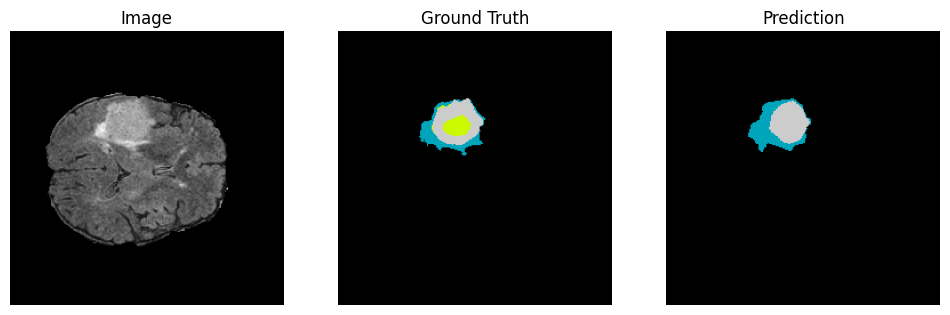

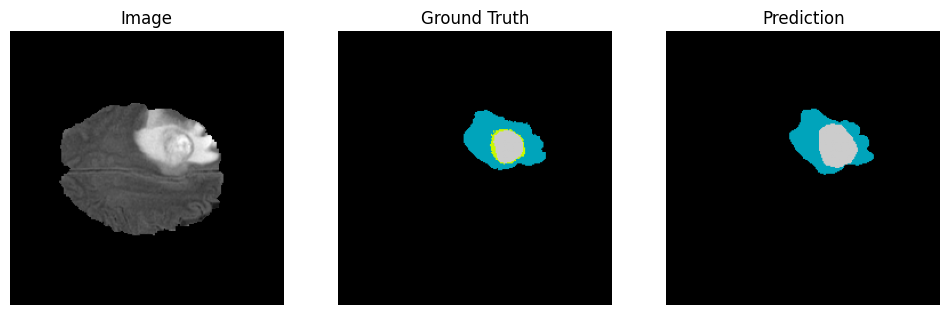

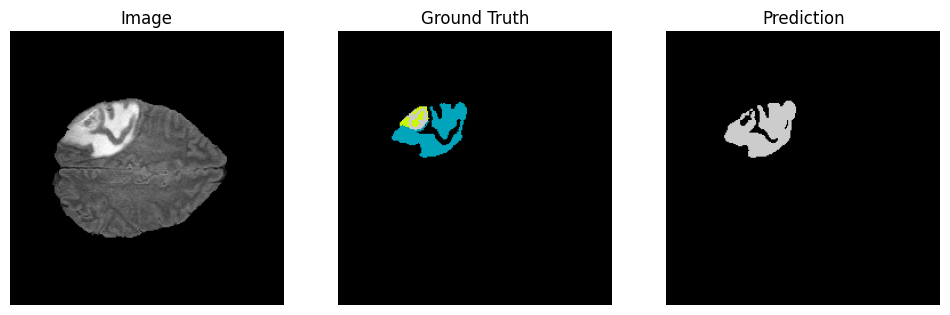

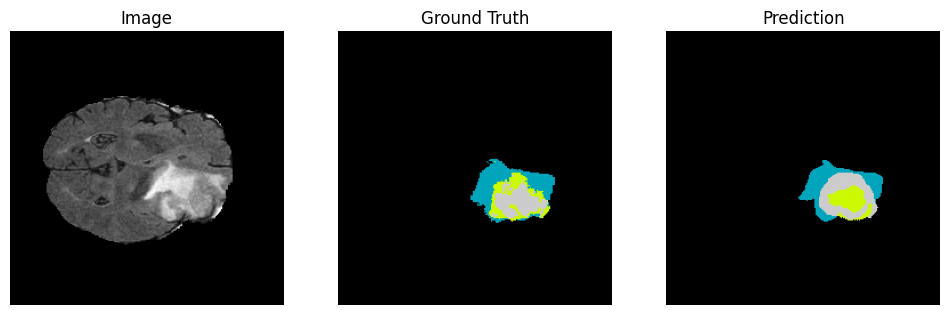

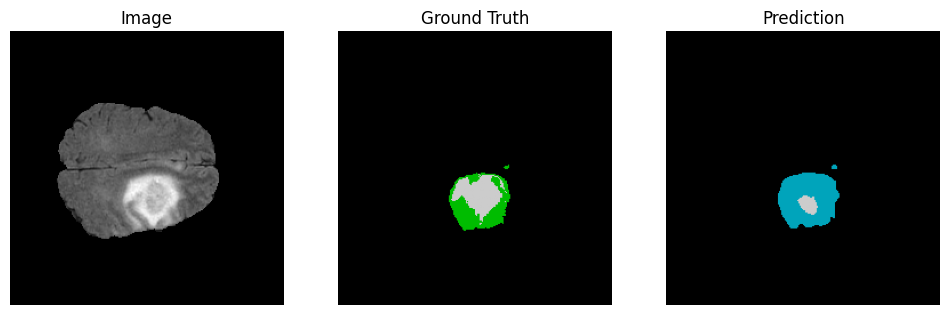

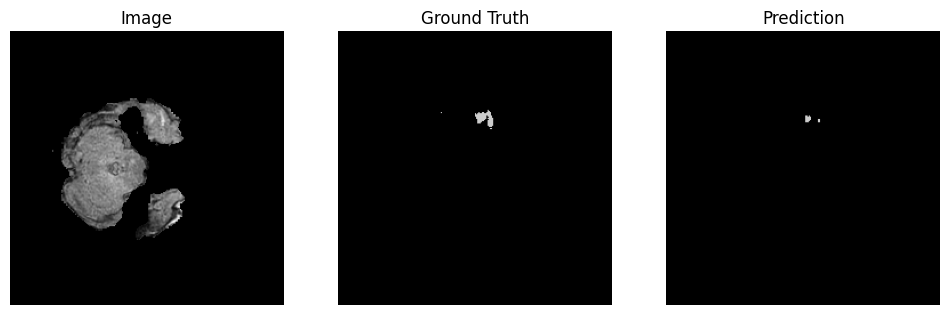

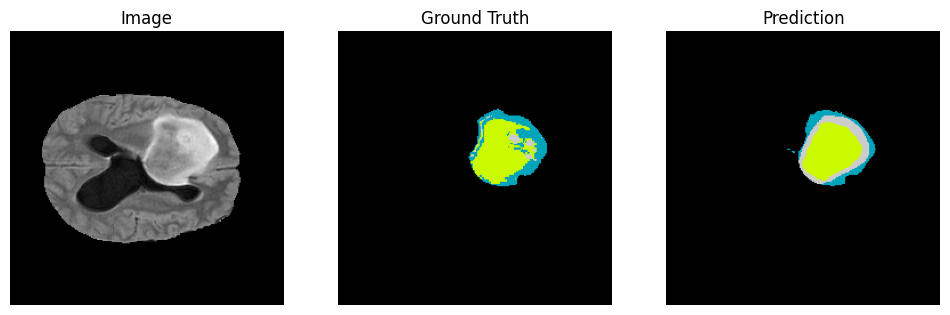

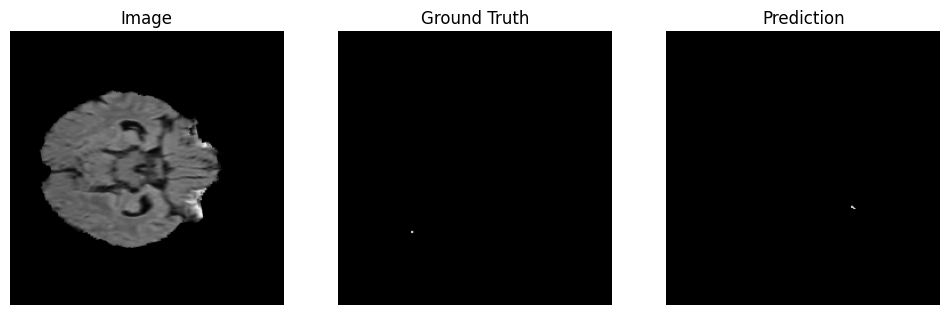

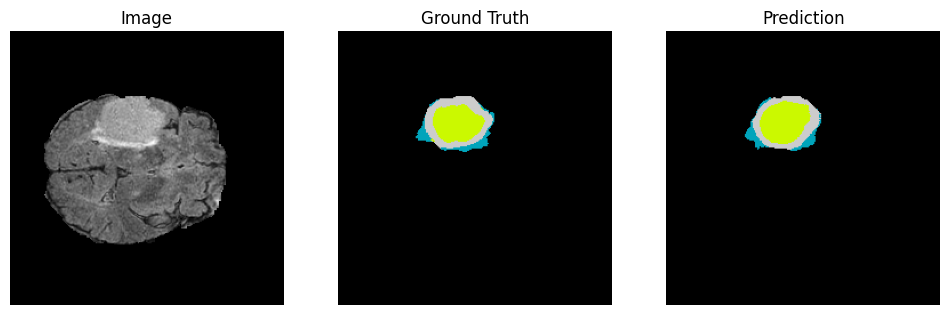

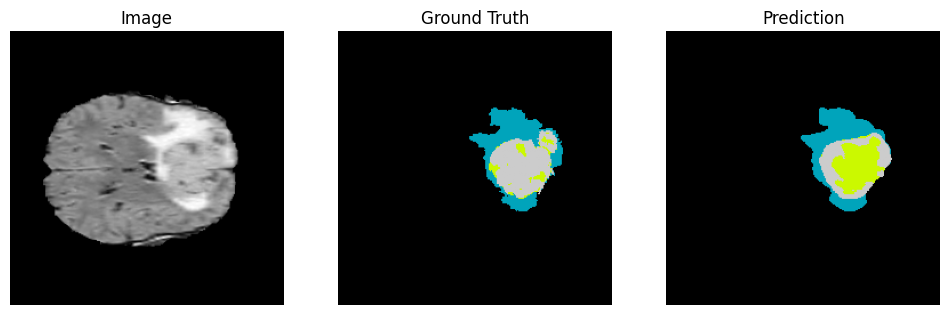

In [23]:
visualize_predictions(model, val_dataset, num_samples=10)

In [33]:
evaluate_model(model, val_dataset)

Evaluating: 100%|████████████████████████████████████████████████████████████████| 6713/6713 [1:03:50<00:00,  1.75it/s]

🧪 Validation Dice Score: 0.6126


In [24]:
evaluate_metrics(model, val_dataset)

Evaluating: 100%|████████████████████████████████████████████████████████████████| 6713/6713 [1:02:22<00:00,  1.79it/s]


📊 Evaluation Summary:
  Pixel Accuracy: 0.9874

🧠 Class 0 Metrics:
  Dice Score : 0.9969
  Precision  : 0.9953
  Recall     : 0.9986

🧠 Class 1 Metrics:
  Dice Score : 0.5624
  Precision  : 0.7395
  Recall     : 0.6807

🧠 Class 2 Metrics:
  Dice Score : 0.3699
  Precision  : 0.5472
  Recall     : 0.2164

🧠 Class 3 Metrics:
  Dice Score : 0.5214
  Precision  : 0.4591
  Recall     : 0.5274


(array([0.99692354, 0.56236486, 0.36986775, 0.52135255]),
 0.9874470037406691,
 array([0.99525727, 0.73946099, 0.54717293, 0.45911255]),
 array([0.99863447, 0.68066695, 0.21643383, 0.52739616]))